# Figures

Generate figures for main text and SI

In [12]:
import numpy as np
import pandas as pd
import json, os, random, pickle
from copy import deepcopy
from types import SimpleNamespace

import torch
import torch.nn.functional as F
from torch.nn import Linear, Dropout, BatchNorm1d, Sequential, ReLU
from torch_geometric.nn import GCNConv, GINEConv, GATv2Conv, global_mean_pool
from torch_geometric.loader import DataLoader
from torch.optim import Adam

from scipy.special import expit
from scipy.optimize import minimize_scalar

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    average_precision_score, precision_score,
    recall_score, classification_report, roc_curve
)
from xgboost import XGBClassifier

import sys
from pathlib import Path
sys.path.append(str(Path(PATH TO PBSG)))


import pbsg
from pbsg.polymer import polymers_from_df
from pbsg.polymer.generators import smiles_from_graphs
from pbsg.ml import to_pyg
from pbsg.ml.pyg import architecture_onehot
from pbsg.polymer.parser import parse_smiles_list
import ast

def safe_parse(val):
    try:
        if pd.isna(val): return None
    except (TypeError, ValueError): pass
    while isinstance(val, str):
        try: val = ast.literal_eval(val)
        except (ValueError, SyntaxError): break
    return val

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

In [6]:
df = pd.read_csv('data_regressor.csv')
for col in ['beads_list', 'lengths', 'reactivity_ratios', 'spatiality_rules']:
    if col in df.columns:
        df[col] = df[col].apply(safe_parse)
df['lengths']             = df['lengths'].apply(lambda x: None if isinstance(x, str) else x)
df['architecture_onehot'] = df.apply(architecture_onehot, axis=1)
df['beads_list']          = df['repeat_units'].apply(parse_smiles_list)

In [13]:
with open("random_stratified_splits_reg.json") as f:
    splits = json.load(f)

folds        = splits["folds"]
test_idx     = splits["test"]
all_idx      = np.arange(len(df))
trainval_idx = np.setdiff1d(all_idx, test_idx)
print(f"trainval={len(trainval_idx)}  test={len(test_idx)}  folds={len(folds)}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

trainval=345  test=62  folds=5
Device: cpu


In [14]:
import importlib
import scripts.fig_test_results_regressor

# After you make a change to the .py file, run this:
importlib.reload(scripts.fig_test_results_regressor)

<module 'scripts.fig_test_results_regressor' from '/Users/xgv7306/Library/CloudStorage/OneDrive-NorthwesternUniversity/northwestern/2-PolyID:Dora/polymer_melting_temp_ML/Regressor/scripts/fig_test_results_regressor.py'>

In [11]:
simple_color = "#2ca02c"   
simple_dec_color= "#ff7f0e"  
gnn_color    = "#BD2D87" 

In [15]:
# Regression figures (in regression notebook)
from scripts.fig_test_results_regressor import run_all_fig
run_all_fig(df, trainval_idx, test_idx)

gatv2_pbsg
#BD2D87
xgb_fp_pooled_ru
#2ca02c
xgb_fp_pooled_poly
#ff7f0e
Saved: Figures/fig_pred_vs_actual.pdf
Saved: Figures/fig_residuals_stereo.pdf
Saved: Figures/fig_subgroup_mae_stereo.pdf
Saved: Figures/fig_subgroup_mae_arch.pdf
Saved: Figures/fig_tm_distribution.pdf

All Figure panels saved.


In [16]:
import importlib
import scripts.figs_cv_boxplots

# After you make a change to the .py file, run this:
importlib.reload(scripts.figs_cv_boxplots)

<module 'scripts.figs_cv_boxplots' from '/Users/xgv7306/Library/CloudStorage/OneDrive-NorthwesternUniversity/northwestern/2-PolyID:Dora/polymer_melting_temp_ML/Regressor/scripts/figs_cv_boxplots.py'>

In [17]:
# SI: CV box plots
from scripts.figs_cv_boxplots import plot_cv_boxplots_cls, plot_cv_boxplots_reg
plot_cv_boxplots_reg()   # needs cv_results_folds_reg.csv

Saved: Figures/figS_cv_boxplots_reg.pdf


In [18]:
import importlib
import scripts.figs_learning_curves

# After you make a change to the .py file, run this:
importlib.reload(scripts.figs_learning_curves)

<module 'scripts.figs_learning_curves' from '/Users/xgv7306/Library/CloudStorage/OneDrive-NorthwesternUniversity/northwestern/2-PolyID:Dora/polymer_melting_temp_ML/Regressor/scripts/figs_learning_curves.py'>

In [19]:
from scripts.figs_learning_curves import plot_learning_curves_cls, plot_learning_curves_reg
plot_learning_curves_reg()

Saved: Figures/figS_learning_curve_reg.pdf


In [20]:
import importlib
import scripts.fig_reg_supp

importlib.reload(scripts.fig_reg_supp)

<module 'scripts.fig_reg_supp' from '/Users/xgv7306/Library/CloudStorage/OneDrive-NorthwesternUniversity/northwestern/2-PolyID:Dora/polymer_melting_temp_ML/Regressor/scripts/fig_reg_supp.py'>

In [21]:
from scripts.fig_reg_supp import plot_reg_split_validation

plot_reg_split_validation(df, trainval_idx, test_idx)

Saved: Figures/fig_reg_split_validation.pdf


In [3]:
from dov import DomainOfValidity
import joblib

In [4]:
dov=joblib.load("dov_reg.pkl")

In [9]:
# Score test set
result_df = dov.score_df(
    query_smiles = df.iloc[test_idx]["repeat_units"].tolist(),
    query_stereo = df.iloc[test_idx]["stereo_class"].tolist(),
)

print(result_df["in_domain_chem"].value_counts())
print(result_df["reliability"].value_counts())
print("\nOOD polymers:")
print(result_df[~result_df["in_domain_chem"]][["smiles","stereo","dov_score","reliability"]])

in_domain_chem
True     61
False     1
Name: count, dtype: int64
reliability
High        56
Moderate     5
Very low     1
Low          0
Name: count, dtype: int64

OOD polymers:
                                               smiles   stereo  dov_score  \
47  [*]C1=CC=C(C(C2=CC=C(OC3=CC=C(O[*])C=C3)C=C2)=...  achiral      0.241   

   reliability  
47    Very low  


In [15]:
with open("test_predictions_reg_full.json") as f:
    test_results_reg = json.load(f)
print(test_results_reg.keys())

dict_keys(['gcn_pbsg', 'gcn_smiles', 'gcn_smiles_gl', 'gine_pbsg', 'gine_smiles', 'gine_smiles_gl', 'gatv2_pbsg', 'gatv2_smiles', 'gatv2_smiles_gl', 'rr_fp_pooled_ru', 'rr_fp_ru', 'rr_fp_pooled_poly', 'rr_fp_poly', 'rf_fp_pooled_ru', 'rf_fp_ru', 'rf_fp_pooled_poly', 'rf_fp_poly', 'xgb_fp_pooled_ru', 'xgb_fp_ru', 'xgb_fp_pooled_poly', 'xgb_fp_poly'])


In [21]:
import importlib
import scripts.figs_dov

# After you make a change to the .py file, run this:
importlib.reload(scripts.figs_dov)

<module 'scripts.figs_dov' from '/Users/xgv7306/Library/CloudStorage/OneDrive-NorthwesternUniversity/northwestern/2-PolyID:Dora/polymer_melting_temp_ML/Regressor/scripts/figs_dov.py'>

In [10]:
result_df

,smiles,stereo,dov_score,in_domain_chem,stereo_covered,in_domain_full,reliability
0,[*]OC(C)CC([*])=O.[*]C(CC(CC)O[*])=O,isotactic,1.0000,True,True,True,High
1,[*]OC(C)CC([*])=O.[*]C(CC(CC)O[*])=O,isotactic,1.0000,True,True,True,High
2,[*]C(CC(COc1ccc(C)cc1)O[*])=O.[*]C(CC(CCCOc1cc...,isotactic,0.5164,True,True,True,Moderate
3,[*]OC(CC(OC(C)CC([*])=O)=O)C.[*]OC(CC(OC(CC)CC...,atactic,1.0000,True,True,True,High
4,[*]OC(C)CC([*])=O,isotactic,1.0000,True,True,True,High
...,...,...,...,...,...,...,...
57,[*]OC(CC(OC(C)CC([*])=O)=O)C.[*]OC(CC(OC(CC)CC...,atactic,1.0000,True,True,True,High
58,[*]OC(C)CC([*])=O.[*]C(CCCO[*])=O,isotactic,1.0000,True,True,True,High
59,[*]OC(CC(C)[*])=O.[*]C(CCCCCO[*])=O,isotactic,1.0000,True,True,True,High
60,COC(C=CC=C1)=C1CC([*])C[*].[*]C(C1=CC=CC=C1)C[*],syndiotactic,1.0000,True,True,True,High


In [22]:
from scripts.figs_dov import plot_dov_reg, plot_reg_efficiency
plot_dov_reg(dov, result_df, test_results_reg, best_model_key='xgb_fp_pooled_ru')

[84.25233459472656]
[84.25233459472656, nan]
[84.25233459472656, nan, 23.445248413085938]
[84.25233459472656, nan, 23.445248413085938, 10.981912681034633]
Saved: ./figS_dov_reg.pdf


In [11]:
result_df

,smiles,stereo,dov_score,in_domain_chem,stereo_covered,in_domain_full,reliability
0,[*]OC(C)CC([*])=O.[*]C(CC(CC)O[*])=O,isotactic,1.0000,True,True,True,High
1,[*]OC(C)CC([*])=O.[*]C(CC(CC)O[*])=O,isotactic,1.0000,True,True,True,High
2,[*]C(CC(COc1ccc(C)cc1)O[*])=O.[*]C(CC(CCCOc1cc...,isotactic,0.5164,True,True,True,Moderate
3,[*]OC(CC(OC(C)CC([*])=O)=O)C.[*]OC(CC(OC(CC)CC...,atactic,1.0000,True,True,True,High
4,[*]OC(C)CC([*])=O,isotactic,1.0000,True,True,True,High
...,...,...,...,...,...,...,...
57,[*]OC(CC(OC(C)CC([*])=O)=O)C.[*]OC(CC(OC(CC)CC...,atactic,1.0000,True,True,True,High
58,[*]OC(C)CC([*])=O.[*]C(CCCO[*])=O,isotactic,1.0000,True,True,True,High
59,[*]OC(CC(C)[*])=O.[*]C(CCCCCO[*])=O,isotactic,1.0000,True,True,True,High
60,COC(C=CC=C1)=C1CC([*])C[*].[*]C(C1=CC=CC=C1)C[*],syndiotactic,1.0000,True,True,True,High


In [26]:
labels = np.array(test_results_reg['xgb_fp_pooled_ru']["labels"])
preds  = np.array(test_results_reg['xgb_fp_pooled_ru']["preds"])
in_dom = result_df["in_domain_chem"].values   # boolean in-domain flag

# the single lowest-DoV point
worst_idx = result_df["dov_score"].values.argmin()
print("lowest-DoV point abs error:", abs(labels[worst_idx]-preds[worst_idx]))

# in-domain MAE (excluding out-of-domain points)
print("in-domain MAE:", np.mean(np.abs(labels[in_dom]-preds[in_dom])))
# also: MAE excluding just the worst point, for comparison

lowest-DoV point abs error: 84.25233459472656
in-domain MAE: 12.003497577104412


In [29]:
df=pd.read_csv('polyID_reg_preds.csv')

In [30]:
df_test=pd.read_csv('polyID_reg_test_preds.csv')

R²:   0.4194
MAE:  32.73°C
RMSE: 50.01°C
n:    407


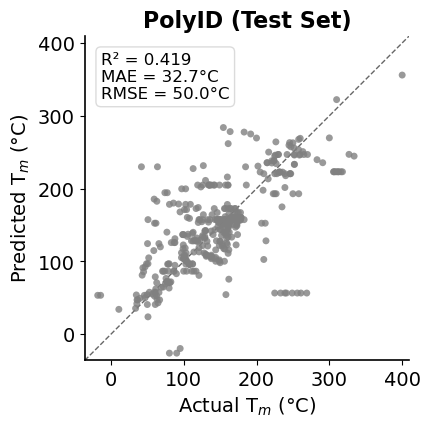

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error

# Load your comparison results
# df_comp = pd.read_csv("their_model_preds.csv")  # adjust path

labels_comp = df["Tm"].values
preds_comp  = df["Melt_Temp_pred"].values

# Drop NaN
valid = ~(np.isnan(labels_comp) | np.isnan(preds_comp))
labels_comp = labels_comp[valid]
preds_comp  = preds_comp[valid]

r2   = r2_score(labels_comp, preds_comp)
mae  = mean_absolute_error(labels_comp, preds_comp)
rmse = float(np.sqrt(np.mean((labels_comp - preds_comp)**2)))

print(f"R²:   {r2:.4f}")
print(f"MAE:  {mae:.2f}°C")
print(f"RMSE: {rmse:.2f}°C")
print(f"n:    {valid.sum()}")

fig, ax = plt.subplots(figsize=(4.5, 4.5))

ax.scatter(labels_comp, preds_comp, alpha=0.8, s=25,
           color="#808080", edgecolors="none", zorder=2)

lim = [min(labels_comp.min(), preds_comp.min()) - 10,
       max(labels_comp.max(), preds_comp.max()) + 10]
ax.plot(lim, lim, "k--", lw=1, alpha=0.6, zorder=1)

ax.text(0.05, 0.95,
        f"R² = {r2:.3f}\nMAE = {mae:.1f}°C\nRMSE = {rmse:.1f}°C",
        transform=ax.transAxes, fontsize=12,
        va="top", ha="left",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                  edgecolor="lightgrey", alpha=0.8))

ax.set_xlabel("Actual T$_m$ (°C)", fontsize=14)
ax.set_ylabel("Predicted T$_m$ (°C)", fontsize=14)
ax.set_title("PolyID (Test Set)", fontsize=16, fontweight="bold")
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.tick_params(labelsize=14)
ax.set_aspect("equal")

plt.tight_layout()
#plt.savefig("figures/comparison_model_parity.pdf", dpi=300, bbox_inches="tight")
plt.show()

R²:   0.4254
MAE:  31.90°C
RMSE: 49.77°C
n:    62


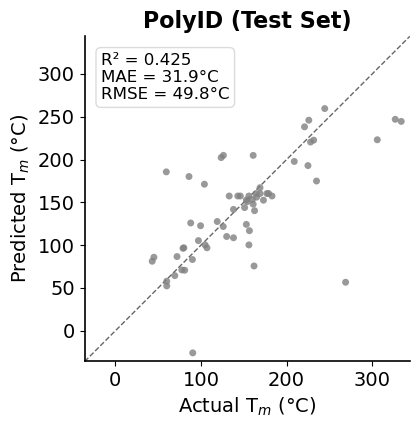

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error

# Load your comparison results
# df_comp = pd.read_csv("their_model_preds.csv")  # adjust path

labels_comp = df_test["Tm"].values
preds_comp  = df_test["Melt_Temp_pred"].values

# Drop NaN
valid = ~(np.isnan(labels_comp) | np.isnan(preds_comp))
labels_comp = labels_comp[valid]
preds_comp  = preds_comp[valid]

r2   = r2_score(labels_comp, preds_comp)
mae  = mean_absolute_error(labels_comp, preds_comp)
rmse = float(np.sqrt(np.mean((labels_comp - preds_comp)**2)))

print(f"R²:   {r2:.4f}")
print(f"MAE:  {mae:.2f}°C")
print(f"RMSE: {rmse:.2f}°C")
print(f"n:    {valid.sum()}")

fig, ax = plt.subplots(figsize=(4.5, 4.5))

ax.scatter(labels_comp, preds_comp, alpha=0.8, s=25,
           color="#808080", edgecolors="none", zorder=2)

lim = [min(labels_comp.min(), preds_comp.min()) - 10,
       max(labels_comp.max(), preds_comp.max()) + 10]
ax.plot(lim, lim, "k--", lw=1, alpha=0.6, zorder=1)

ax.text(0.05, 0.95,
        f"R² = {r2:.3f}\nMAE = {mae:.1f}°C\nRMSE = {rmse:.1f}°C",
        transform=ax.transAxes, fontsize=12,
        va="top", ha="left",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                  edgecolor="lightgrey", alpha=0.8))

ax.set_xlabel("Actual T$_m$ (°C)", fontsize=14)
ax.set_ylabel("Predicted T$_m$ (°C)", fontsize=14)
ax.set_title("PolyID (Test Set)", fontsize=16, fontweight="bold")
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.tick_params(labelsize=14)
ax.set_aspect("equal")

plt.tight_layout()
#plt.savefig("figures/comparison_model_parity.pdf", dpi=300, bbox_inches="tight")
plt.show()